In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

In [73]:
data = pd.read_csv('tested.csv', index_col=0)
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


<Axes: ylabel='PassengerId'>

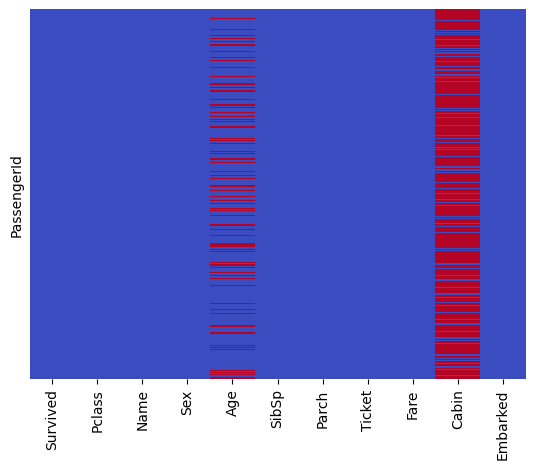

In [74]:
sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

<Axes: xlabel='Survived', ylabel='count'>

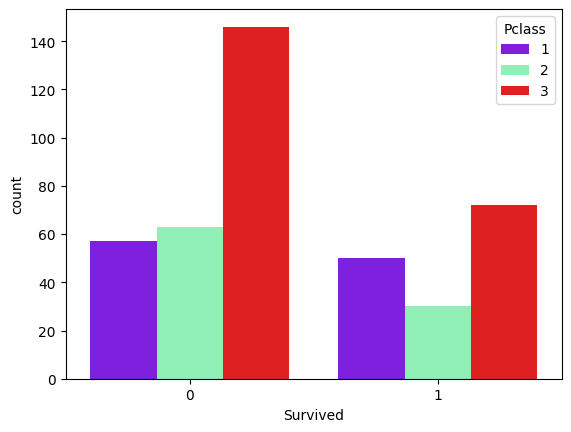

In [75]:
sns.countplot(x='Survived',hue='Pclass',data=data,palette='rainbow')

<Axes: xlabel='Survived', ylabel='count'>

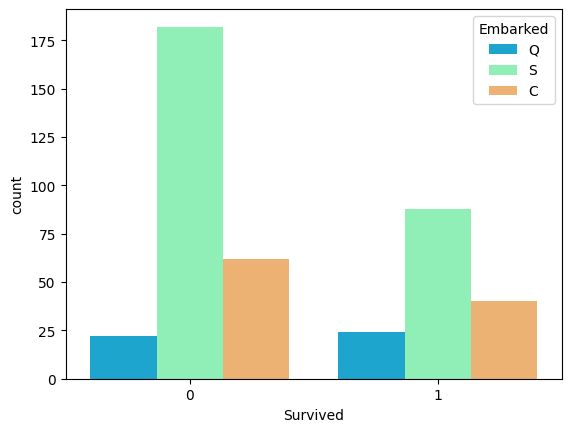

In [76]:
sns.countplot(x='Survived',hue='Embarked',data=data,palette='rainbow')

<Axes: >

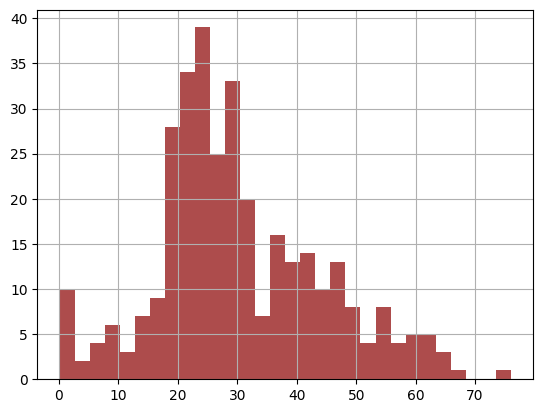

In [77]:
data['Age'].hist(bins=30,color='darkred',alpha=0.7)

<Axes: xlabel='SibSp', ylabel='count'>

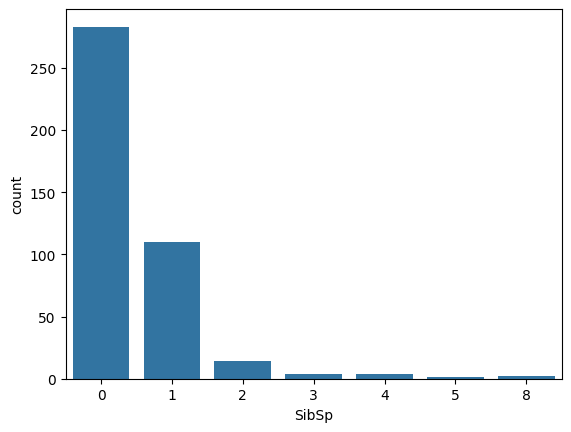

In [78]:
sns.countplot(x='SibSp',data=data)

<Axes: >

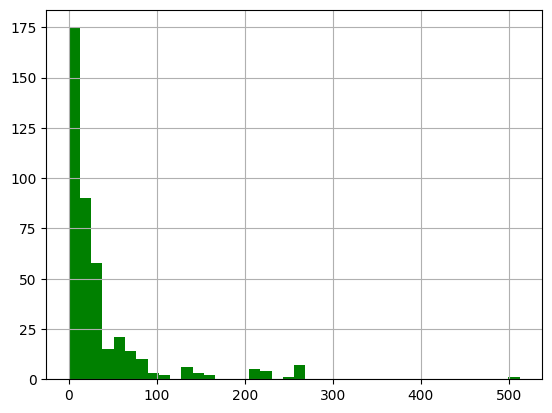

In [79]:
data['Fare'].hist(color='green',bins=40)

<Axes: xlabel='Pclass', ylabel='Age'>

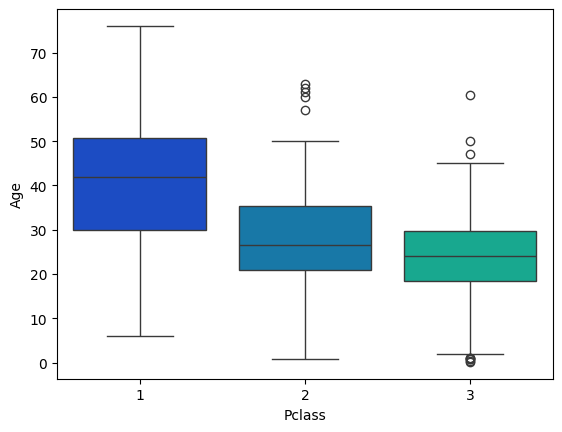

In [80]:
sns.boxplot(x='Pclass',y='Age',data=data,palette='winter')

In [81]:
def fill_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        return round(np.mean(data[data['Pclass']==Pclass]['Age']))
    else:
        return Age

<Axes: ylabel='PassengerId'>

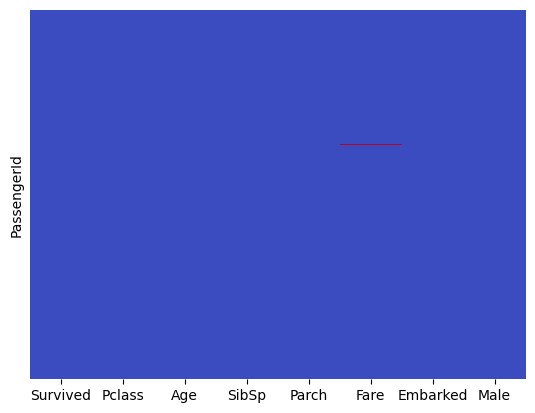

In [82]:
data['Age'] = data[['Age','Pclass']].apply(fill_age,axis=1)
data['Male'] = data['Sex'].map({'female':0,'male':1})


data.drop(['Cabin','Name','Sex','Ticket'],axis=1,inplace=True)

sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

In [83]:
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 892 to 1309
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  417 non-null    int64  
 1   Pclass    417 non-null    int64  
 2   Age       417 non-null    float64
 3   SibSp     417 non-null    int64  
 4   Parch     417 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  417 non-null    object 
 7   Male      417 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 29.3+ KB


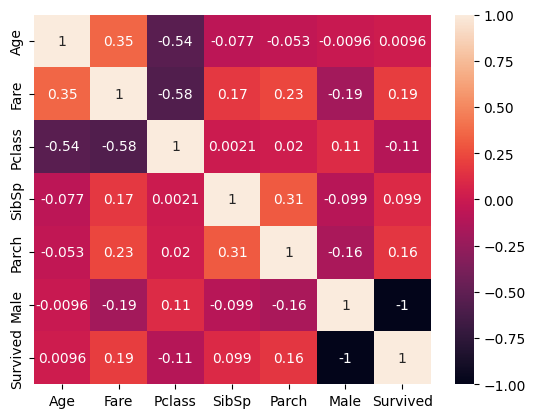

In [84]:
sns.heatmap(data[['Age','Fare','Pclass','SibSp','Parch','Male','Survived']].corr(), annot=True)
plt.show()

In [85]:
df = data[['Age','Fare','Pclass','Parch','Male','Survived']]
X_train, X_test, y_train, y_test = train_test_split(df.drop('Survived',axis=1), 
                                                    df['Survived'], test_size=0.3, 
                                                    random_state=5)

In [86]:
model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=2)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        55

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126

